# Effect of temporal contact graph length on mobility inference
This notebook reproduces Figure 5 from the precomputed experimental results.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

INPUT_DIR = Path(".")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

ORDER_FILTER = None
Y_MAX = 0.5
LEGEND_NCOLS = 4

## Load precomputed data

In [4]:
def read_recovery_csv(path):
    df = pd.read_csv(path, sep=None, engine="python")
    required = {"k_start", "err1", "err2"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")
    df = df[["k_start", "err1", "err2"]].copy()
    df[["k_start", "err1", "err2"]] = df[["k_start", "err1", "err2"]].apply(pd.to_numeric, errors="raise")
    return df.sort_values("k_start")

def dataset_label(path):
    return Path(path).stem.replace("_limited_data_recovery", "").replace("_", " ").split()[0]

csv_files = sorted(INPUT_DIR.glob("*_limited_data_recovery.csv"))

if ORDER_FILTER is not None:
    csv_files = [p for p in csv_files if f"_order_{ORDER_FILTER}_" in p.name]

if not csv_files:
    raise FileNotFoundError("No *_limited_data_recovery.csv files found")

rows = []
for path in csv_files:
    df = read_recovery_csv(path)
    for row in df.itertuples(index=False):
        rows.append({"dataset": dataset_label(path), "k_start": int(row.k_start), "err1": float(row.err1), "err2": float(row.err2)})

data = pd.DataFrame(rows)
data

,dataset,k_start,err1,err2
0,Amsterdam,1000,0.138700,0.372643
1,Amsterdam,10000,0.091361,0.357374
2,Amsterdam,100000,0.066601,0.281429
3,Amsterdam,1000000,0.061562,0.258182
4,Amsterdam,10000000,0.026930,0.204175
5,Budapest,1000,0.159605,0.268026
6,Budapest,10000,0.162943,0.199350
7,Budapest,100000,0.086426,0.209443
8,Budapest,1000000,0.081931,0.170051
9,Budapest,10000000,0.026383,0.128408


## Reproduce Figure 5

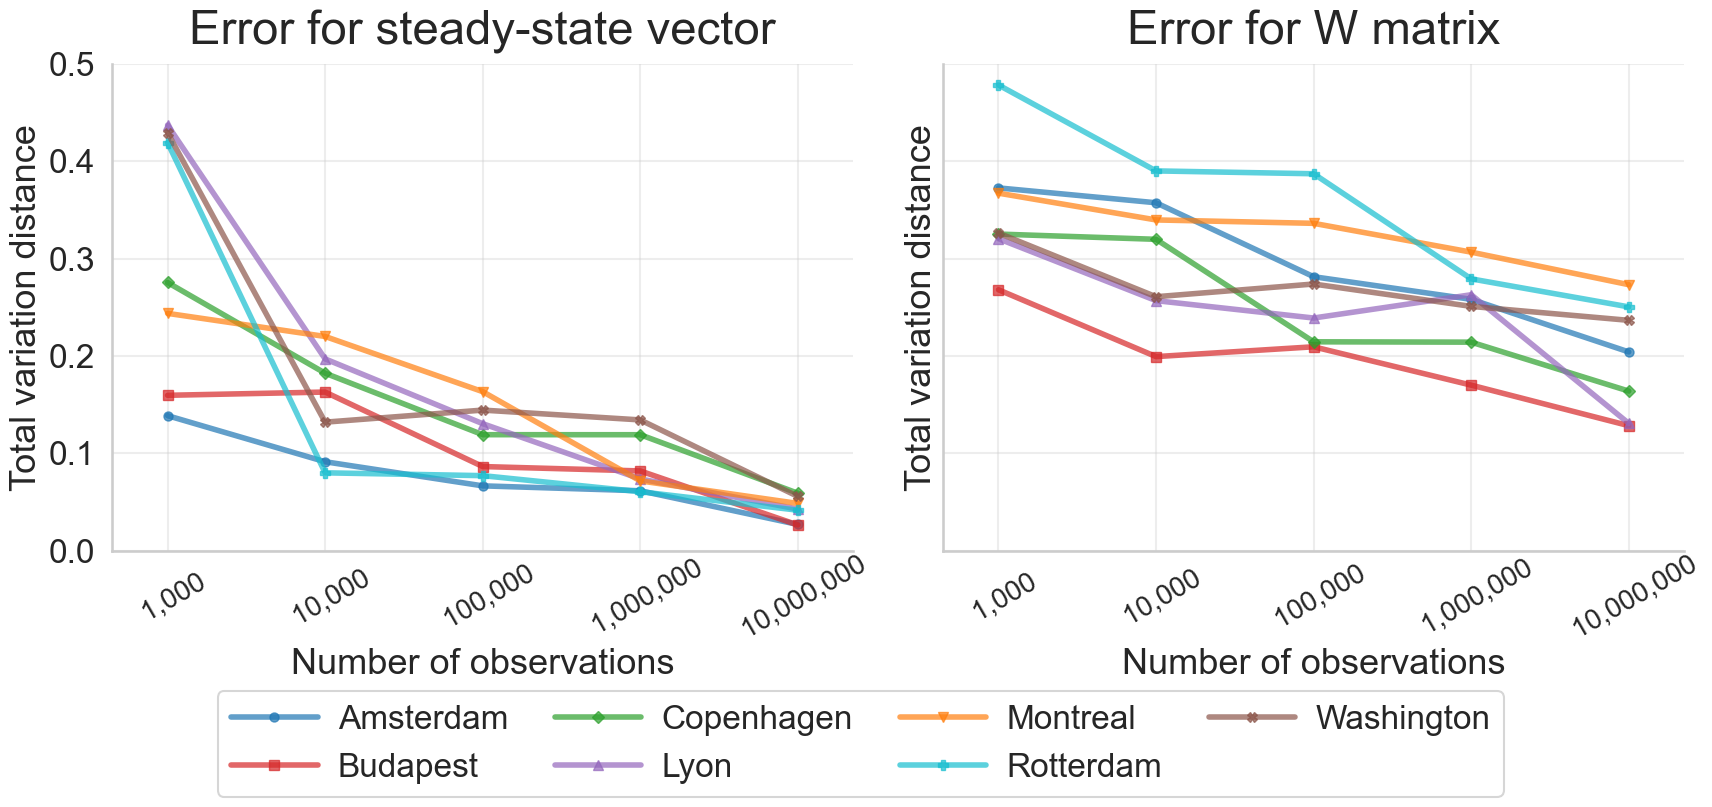

In [3]:
k_values = sorted(data["k_start"].unique())
k_to_pos = {k: i for i, k in enumerate(k_values)}
data["k_pos"] = data["k_start"].map(k_to_pos)

datasets = sorted(data["dataset"].unique())
markers = ["o", "s", "D", "^", "v", "P", "X", "*", "<", ">", "h", "H", "8", "p", "d"]
palette = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e", "#17becf", "#8c564b"] if len(datasets) <= 7 else sns.color_palette("tab20" if len(datasets) <= 20 else "husl", len(datasets))
colors = dict(zip(datasets, palette))

sns.set_theme(context="talk", style="whitegrid", font_scale=0.9)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17.5, 7.2), sharey=True)

for i, dataset in enumerate(datasets):
    sub = data[data["dataset"] == dataset].sort_values("k_start")
    kwargs = dict(label=dataset, color=colors[dataset], marker=markers[i % len(markers)], linewidth=4, markersize=6.5, alpha=0.7)
    ax1.plot(sub["k_pos"], sub["err1"], **kwargs)
    ax2.plot(sub["k_pos"], sub["err2"], **kwargs)

x = range(len(k_values))
labels = [f"{k:,}" for k in k_values]

for ax, title in [(ax1, "Error for steady-state vector"), (ax2, "Error for W matrix")]:
    ax.set_title(title, fontsize=34, pad=14)
    ax.set_xlabel("Number of observations", fontsize=26)
    ax.set_ylabel("Total variation distance", fontsize=26)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="center", rotation_mode="anchor")
    ax.set_xlim(-0.35, len(k_values) - 0.65)
    ax.set_ylim(0, Y_MAX)
    ax.tick_params(axis="x", labelsize=20, pad=16)
    ax.tick_params(axis="y", labelsize=24)
    ax.grid(True, which="major", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=LEGEND_NCOLS, frameon=True, fontsize=24, handlelength=2.6, columnspacing=1.4, handletextpad=0.6)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure_5.png", dpi=600, bbox_inches="tight")
plt.show()